In [1]:
#dqn

In [2]:
#https://github.com/openai/gym/blob/master/gym/envs/classic_control/acrobot.py

In [3]:
#https://github.com/eugeniaring/Medium-Articles/blob/main/Pytorch/acrobot.ipynb

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pickle

In [6]:
"""classic Acrobot task"""
from typing import Optional

import numpy as np
from numpy import cos, pi, sin

np.float_ = np.float64

from gym import core, logger, spaces
from gym.error import DependencyNotInstalled

__copyright__ = "Copyright 2013, RLPy http://acl.mit.edu/RLPy"
__credits__ = [
    "Alborz Geramifard",
    "Robert H. Klein",
    "Christoph Dann",
    "William Dabney",
    "Jonathan P. How",
]
__license__ = "BSD 3-Clause"
__author__ = "Christoph Dann <cdann@cdann.de>"

# SOURCE:
# https://github.com/rlpy/rlpy/blob/master/rlpy/Domains/Acrobot.py
from gym.envs.classic_control import utils


class Custom_AcrobotEnv(core.Env):
    """
    ### Description
    The Acrobot environment is based on Sutton's work in
    ["Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding"](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html)
    and [Sutton and Barto's book](http://www.incompleteideas.net/book/the-book-2nd.html).
    The system consists of two links connected linearly to form a chain, with one end of
    the chain fixed. The joint between the two links is actuated. The goal is to apply
    torques on the actuated joint to swing the free end of the linear chain above a
    given height while starting from the initial state of hanging downwards.
    As seen in the **Gif**: two blue links connected by two green joints. The joint in
    between the two links is actuated. The goal is to swing the free end of the outer-link
    to reach the target height (black horizontal line above system) by applying torque on
    the actuator.
    ### Action Space
    The action is discrete, deterministic, and represents the torque applied on the actuated
    joint between the two links.
    | Num | Action                                | Unit         |
    |-----|---------------------------------------|--------------|
    | 0   | apply -1 torque to the actuated joint | torque (N m) |
    | 1   | apply 0 torque to the actuated joint  | torque (N m) |
    | 2   | apply 1 torque to the actuated joint  | torque (N m) |
    ### Observation Space
    The observation is a `ndarray` with shape `(6,)` that provides information about the
    two rotational joint angles as well as their angular velocities:
    | Num | Observation                  | Min                 | Max               |
    |-----|------------------------------|---------------------|-------------------|
    | 0   | Cosine of `theta1`           | -1                  | 1                 |
    | 1   | Sine of `theta1`             | -1                  | 1                 |
    | 2   | Cosine of `theta2`           | -1                  | 1                 |
    | 3   | Sine of `theta2`             | -1                  | 1                 |
    | 4   | Angular velocity of `theta1` | ~ -12.567 (-4 * pi) | ~ 12.567 (4 * pi) |
    | 5   | Angular velocity of `theta2` | ~ -28.274 (-9 * pi) | ~ 28.274 (9 * pi) |
    where
    - `theta1` is the angle of the first joint, where an angle of 0 indicates the first link is pointing directly
    downwards.
    - `theta2` is ***relative to the angle of the first link.***
        An angle of 0 corresponds to having the same angle between the two links.
    The angular velocities of `theta1` and `theta2` are bounded at ±4π, and ±9π rad/s respectively.
    A state of `[1, 0, 1, 0, ..., ...]` indicates that both links are pointing downwards.
    ### Rewards
    The goal is to have the free end reach a designated target height in as few steps as possible,
    and as such all steps that do not reach the goal incur a reward of -1.
    Achieving the target height results in termination with a reward of 0. The reward threshold is -100.
    ### Starting State
    Each parameter in the underlying state (`theta1`, `theta2`, and the two angular velocities) is initialized
    uniformly between -0.1 and 0.1. This means both links are pointing downwards with some initial stochasticity.
    ### Episode End
    The episode ends if one of the following occurs:
    1. Termination: The free end reaches the target height, which is constructed as:
    `-cos(theta1) - cos(theta2 + theta1) > 1.0`
    2. Truncation: Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    ```
    env = gym.make('Acrobot-v1')
    ```
    By default, the dynamics of the acrobot follow those described in Sutton and Barto's book
    [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/11/node4.html).
    However, a `book_or_nips` parameter can be modified to change the pendulum dynamics to those described
    in the original [NeurIPS paper](https://papers.nips.cc/paper/1995/hash/8f1d43620bc6bb580df6e80b0dc05c48-Abstract.html).
    ```
    # To change the dynamics as described above
    env.env.book_or_nips = 'nips'
    ```
    See the following note and
    the [implementation](https://github.com/openai/gym/blob/master/gym/envs/classic_control/acrobot.py) for details:
    > The dynamics equations were missing some terms in the NIPS paper which
            are present in the book. R. Sutton confirmed in personal correspondence
            that the experimental results shown in the paper and the book were
            generated with the equations shown in the book.
            However, there is the option to run the domain with the paper equations
            by setting `book_or_nips = 'nips'`
    ### Version History
    - v1: Maximum number of steps increased from 200 to 500. The observation space for v0 provided direct readings of
    `theta1` and `theta2` in radians, having a range of `[-pi, pi]`. The v1 observation space as described here provides the
    sine and cosine of each angle instead.
    - v0: Initial versions release (1.0.0) (removed from gym for v1)
    ### References
    - Sutton, R. S. (1996). Generalization in Reinforcement Learning: Successful Examples Using Sparse Coarse Coding.
        In D. Touretzky, M. C. Mozer, & M. Hasselmo (Eds.), Advances in Neural Information Processing Systems (Vol. 8).
        MIT Press. https://proceedings.neurips.cc/paper/1995/file/8f1d43620bc6bb580df6e80b0dc05c48-Paper.pdf
    - Sutton, R. S., Barto, A. G. (2018 ). Reinforcement Learning: An Introduction. The MIT Press.
    """

    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 15,
    }

    dt = 0.2

    LINK_LENGTH_1 = 1.0  # [m]
    LINK_LENGTH_2 = 1.0  # [m]
    LINK_MASS_1 = 1.0  #: [kg] mass of link 1
    LINK_MASS_2 = 1.0  #: [kg] mass of link 2
    LINK_COM_POS_1 = 0.5  #: [m] position of the center of mass of link 1
    LINK_COM_POS_2 = 0.5  #: [m] position of the center of mass of link 2
    LINK_MOI = 1.0  #: moments of inertia for both links

    MAX_VEL_1 = 4 * pi
    MAX_VEL_2 = 9 * pi

    AVAIL_TORQUE = [-1.0, 0.0, +1]

    torque_noise_max = 0.0

    SCREEN_DIM = 500

    #: use dynamics equations from the nips paper or the book
    book_or_nips = "book"
    action_arrow = None
    domain_fig = None
    actions_num = 3

    def __init__(self, render_mode: Optional[str] = None):
        self.render_mode = render_mode
        self.screen = None
        self.clock = None
        self.isopen = True
        high = np.array(
            [1.0, 1.0, 1.0, 1.0, self.MAX_VEL_1, self.MAX_VEL_2], dtype=np.float32
        )
        low = -high
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.state = None

                ### Customization changes ######
        self.NumIntegrationsSteps = 1#2010
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60 #60 #300
        dt_prime = self.dt/self.NumIntegrationsSteps
        self.tau1 = dt_prime
        self.MPC.dt = dt_prime
        self.MPC.plant.tau1 = dt_prime
        self.MPC.ref_model.tau1 = dt_prime
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0
        ####

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        # Note that if you use custom reset bounds, it may lead to out-of-bound
        # state/observations.
        low, high = utils.maybe_parse_reset_bounds(
            options, -0.1, 0.1  # default low
        )  # default high
        self.state = self.np_random.uniform(low=low, high=high, size=(4,)).astype(
            np.float32
        )
      ####
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0
      ####
        if self.render_mode == "human":
            self.render()
        return self._get_ob()

    def step(self, a):
        s = self.state


        assert s is not None, "Call reset before using AcrobotEnv object."
        ns=np.asarray(s)
        wanted_torque = self.AVAIL_TORQUE[a]
        #wanted_torque_ret = self.wanted_torque
        self.MPC.y_spf = wanted_torque
        beta_AF = 0.135
        wanted_torque = (beta_AF)*self.wanted_torque+(1-beta_AF)*wanted_torque
        self.wanted_torque = wanted_torque
        self.MPC.y[0] = wanted_torque #self.MPC.y_spf #wanted_torque #wanted_torque_ret
        wanted_torque_ret = self.wanted_torque
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
          self.MPC.plant.thetadot =  ns[2] #ns[3]
          actual_torque = self.MPC.step()
          #actual_torque = wanted_torque # change for perfect applying force

          # Add noise to the force action
          '''
          if self.torque_noise_max > 0:
              actual_torque += self.np_random.uniform(
                  -self.torque_noise_max, self.torque_noise_max
              )
          '''
          # Now, augment the state with our force action so it can be passed to
          # _dsdt
          s_augmented = np.append(ns, actual_torque)
          ns = rk4(self._dsdt, s_augmented, [0, self.tau1])
          ns[0] = wrap(ns[0], -pi, pi)
          ns[1] = wrap(ns[1], -pi, pi)
          ns[2] = bound(ns[2], -self.MAX_VEL_1, self.MAX_VEL_1)
          ns[3] = bound(ns[3], -self.MAX_VEL_2, self.MAX_VEL_2)

        self.state = ns
        terminated = self._terminal()
        reward = -1.0 if not terminated else 0.0

        #if self.render_mode == "human":
        #    self.render()
        return self._get_ob(), reward, terminated, False , wanted_torque_ret, actual_torque

    def _get_ob(self):
        s = self.state
        assert s is not None, "Call reset before using AcrobotEnv object."
        return np.array(
            [cos(s[0]), sin(s[0]), cos(s[1]), sin(s[1]), s[2], s[3]], dtype=np.float32
        )

    def _terminal(self):
        s = self.state
        assert s is not None, "Call reset before using AcrobotEnv object."
        return bool(-cos(s[0]) - cos(s[1] + s[0]) > 1.0)

    def _dsdt(self, s_augmented):
        m1 = self.LINK_MASS_1
        m2 = self.LINK_MASS_2
        l1 = self.LINK_LENGTH_1
        lc1 = self.LINK_COM_POS_1
        lc2 = self.LINK_COM_POS_2
        I1 = self.LINK_MOI
        I2 = self.LINK_MOI
        g = 9.8
        a = s_augmented[-1]
        s = s_augmented[:-1]
        theta1 = s[0]
        theta2 = s[1]
        dtheta1 = s[2]
        dtheta2 = s[3]
        d1 = (
            m1 * lc1**2
            + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * cos(theta2))
            + I1
            + I2
        )
        d2 = m2 * (lc2**2 + l1 * lc2 * cos(theta2)) + I2
        phi2 = m2 * lc2 * g * cos(theta1 + theta2 - pi / 2.0)
        phi1 = (
            -m2 * l1 * lc2 * dtheta2**2 * sin(theta2)
            - 2 * m2 * l1 * lc2 * dtheta2 * dtheta1 * sin(theta2)
            + (m1 * lc1 + m2 * l1) * g * cos(theta1 - pi / 2)
            + phi2
        )
        if self.book_or_nips == "nips":
            # the following line is consistent with the description in the
            # paper
            ddtheta2 = (a + d2 / d1 * phi1 - phi2) / (m2 * lc2**2 + I2 - d2**2 / d1)
        else:
            # the following line is consistent with the java implementation and the
            # book
            ddtheta2 = (
                a + d2 / d1 * phi1 - m2 * l1 * lc2 * dtheta1**2 * sin(theta2) - phi2
            ) / (m2 * lc2**2 + I2 - d2**2 / d1)
        ddtheta1 = -(d2 * ddtheta2 + phi1) / d1
        return dtheta1, dtheta2, ddtheta1, ddtheta2, 0.0

    def render(self):
        if self.render_mode is None:
            logger.warn(
                "You are calling render method without specifying any render mode. "
                "You can specify the render_mode at initialization, "
                f'e.g. gym("{self.spec.id}", render_mode="rgb_array")'
            )
            return

        try:
            import pygame
            from pygame import gfxdraw
        except ImportError:
            raise DependencyNotInstalled(
                "pygame is not installed, run `pip install gym[classic_control]`"
            )

        if self.screen is None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.screen = pygame.display.set_mode(
                    (self.SCREEN_DIM, self.SCREEN_DIM)
                )
            else:  # mode in "rgb_array"
                self.screen = pygame.Surface((self.SCREEN_DIM, self.SCREEN_DIM))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        surf = pygame.Surface((self.SCREEN_DIM, self.SCREEN_DIM))
        surf.fill((255, 255, 255))
        s = self.state

        bound = self.LINK_LENGTH_1 + self.LINK_LENGTH_2 + 0.2  # 2.2 for default
        scale = self.SCREEN_DIM / (bound * 2)
        offset = self.SCREEN_DIM / 2

        if s is None:
            return None

        p1 = [
            -self.LINK_LENGTH_1 * cos(s[0]) * scale,
            self.LINK_LENGTH_1 * sin(s[0]) * scale,
        ]

        p2 = [
            p1[0] - self.LINK_LENGTH_2 * cos(s[0] + s[1]) * scale,
            p1[1] + self.LINK_LENGTH_2 * sin(s[0] + s[1]) * scale,
        ]

        xys = np.array([[0, 0], p1, p2])[:, ::-1]
        thetas = [s[0] - pi / 2, s[0] + s[1] - pi / 2]
        link_lengths = [self.LINK_LENGTH_1 * scale, self.LINK_LENGTH_2 * scale]

        pygame.draw.line(
            surf,
            start_pos=(-2.2 * scale + offset, 1 * scale + offset),
            end_pos=(2.2 * scale + offset, 1 * scale + offset),
            color=(0, 0, 0),
        )

        for ((x, y), th, llen) in zip(xys, thetas, link_lengths):
            x = x + offset
            y = y + offset
            l, r, t, b = 0, llen, 0.1 * scale, -0.1 * scale
            coords = [(l, b), (l, t), (r, t), (r, b)]
            transformed_coords = []
            for coord in coords:
                coord = pygame.math.Vector2(coord).rotate_rad(th)
                coord = (coord[0] + x, coord[1] + y)
                transformed_coords.append(coord)
            gfxdraw.aapolygon(surf, transformed_coords, (0, 204, 204))
            gfxdraw.filled_polygon(surf, transformed_coords, (0, 204, 204))

            gfxdraw.aacircle(surf, int(x), int(y), int(0.1 * scale), (204, 204, 0))
            gfxdraw.filled_circle(surf, int(x), int(y), int(0.1 * scale), (204, 204, 0))

        surf = pygame.transform.flip(surf, False, True)
        self.screen.blit(surf, (0, 0))

        if self.render_mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False


def wrap(x, m, M):
    """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
    truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
    For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.
    Args:
        x: a scalar
        m: minimum possible value in range
        M: maximum possible value in range
    Returns:
        x: a scalar, wrapped
    """
    diff = M - m
    while x > M:
        x = x - diff
    while x < m:
        x = x + diff
    return x


def bound(x, m, M=None):
    """Either have m as scalar, so bound(x,m,M) which returns m <= x <= M *OR*
    have m as length 2 vector, bound(x,m, <IGNORED>) returns m[0] <= x <= m[1].
    Args:
        x: scalar
        m: The lower bound
        M: The upper bound
    Returns:
        x: scalar, bound between min (m) and Max (M)
    """
    if M is None:
        M = m[1]
        m = m[0]
    # bound x between min (m) and Max (M)
    return min(max(x, m), M)


def rk4(derivs, y0, t):
    """
    Integrate 1-D or N-D system of ODEs using 4-th order Runge-Kutta.
    Example for 2D system:
        >>> def derivs(x):
        ...     d1 =  x[0] + 2*x[1]
        ...     d2 =  -3*x[0] + 4*x[1]
        ...     return d1, d2
        >>> dt = 0.0005
        >>> t = np.arange(0.0, 2.0, dt)
        >>> y0 = (1,2)
        >>> yout = rk4(derivs, y0, t)
    Args:
        derivs: the derivative of the system and has the signature ``dy = derivs(yi)``
        y0: initial state vector
        t: sample times
    Returns:
        yout: Runge-Kutta approximation of the ODE
    """

    try:
        Ny = len(y0)
    except TypeError:
        yout = np.zeros((len(t),), np.float_)
    else:
        yout = np.zeros((len(t), Ny), np.float_)

    yout[0] = y0

    for i in np.arange(len(t) - 1):

        this = t[i]
        dt = t[i + 1] - this
        dt2 = dt / 2.0
        y0 = yout[i]

        k1 = np.asarray(derivs(y0))
        k2 = np.asarray(derivs(y0 + dt2 * k1))
        k3 = np.asarray(derivs(y0 + dt2 * k2))
        k4 = np.asarray(derivs(y0 + dt * k3))
        yout[i + 1] = y0 + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)
    # We only care about the final timestep and we cleave off action value which will be zero
    return yout[-1][:4]

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
from numpy.linalg import matrix_power
from scipy.linalg import block_diag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
    self.ZOH_mode = True
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0
    self.F = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    if self.ZOH_mode:
      a = np.exp(-self.tau1*self.Resistor_R/self.inductor_L)
      self.current = a*self.current + (1-a)/self.Resistor_R*(u-voltage_BEMF)
    else:
      self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    self.F=f2 #f1 #f2 #(f1+f2)/2
    return self.F # return actual applied torque

  def reset(self):
    self.current = 0.0
    self.F = 0.0


In [9]:
class ReferenceModel():

  def __init__(self):
    self.tau1 = 0.05
    self.A_rm = np.array([[0]])
    self.B_rm = np.array([[0]])
    self.y_rm = np.array([[0]])

  def step(self, u):
    # TODO: complete
    #for _ in range(0,1):
    y_m_prev = self.y_rm+0
    self.y_rm = self.A_rm@self.y_rm + self.B_rm*u
    return self.y_rm #y_m_prev #self.y_rm


  def reset(self):
    self.y_rm = np.array([[0]])




In [10]:
class ModelPredictCtrl:

  def __init__(self,dt=0.01, N=60,
               a_sp = 1, b_sp = 0,
               R_resistor = 1, L_inductor = 0.1,
               k_t=1,k_w=1):
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.dt = dt
    self.a_sp = a_sp
    self.b_sp = b_sp
    self.R_resistor = R_resistor
    self.L_inductor = L_inductor
    self.k_t = k_t
    self.k_w = k_w
    self.N=N
    self.A_pm = None
    self.B_pm = None
    self.A = None
    self.B = None
    self.Atilde = None
    self.Q1 = 15*np.array([[1,-1]])
    self.Q = None
    self.R = None
    self.y_spf = None
    self.K = None
    self.K_MPC = None
    self.y = np.array([[0],[0]])
    self.u = 0


  def ConfigureMPCParams(self):

    # Configure reference model
    A_sp = self.a_sp
    A_rm = np.array([[A_sp]])
    B_rm = np.array([[self.b_sp]])
    self.ref_model.A_rm = A_rm
    self.ref_model.B_rm = B_rm


    # Configure plant model
    dt = self.dt
    # note: self.dt and self.ref_model.tau1 aren't necessarily the same
    A_sp = self.a_sp
    A_pm = np.exp(-self.R_resistor/self.L_inductor*dt)
    B_pm = self.k_t*(1-A_pm)/self.R_resistor
    B = np.array([[self.b_sp],[B_pm]])
    self.A = np.array([[A_sp,0],[0,A_pm]])
    self.B = B


    # Confgure weight matrices Q & R and control gain K_mpc
    N = self.N
    A = self.A
    B = self.B
    B_shape_1 = B.shape[1]

    Atilde = 0
    for n in range(0,N):
      if n==0:
        Atilde = A*1
      else:
        Atilde = np.vstack((Atilde,matrix_power(A, n+1)))
    self.Atilde = Atilde

    Btilde = 0
    for i in range(0,N):
      if i==0:
        Btilde = B*1
      else:
        Btilde = np.hstack((Btilde,B*0))
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = matrix_power(A, i)@B
        elif i>=j:
          row = np.hstack((row,matrix_power(A, i-j)@B))
        else:
          row = np.hstack((row,i*0*B))
      Btilde = np.vstack((Btilde,row))

    Q1 = self.Q1
    Q1_N = Q1+0
    for n in range(1,N):
      Q1_N = block_diag(Q1_N,Q1)
    W_Q = 100*np.eye(N)
    W_Q[0,0] = 500
    Q = ((Q1_N.T)@(W_Q))@Q1_N#####
    self.Q = Q

    I=np.eye(B_shape_1)
    O=0*I

    R1 = 0
    for i in range(0,N):
      if i==0:
        R1 = I
      else:
        R1 = np.hstack((R1,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j:
          Mij = I
        elif i==j+1:
          Mij = -I
        else:
          Mij = O
        row = np.hstack((row,Mij))
      R1 = np.vstack((R1,row))

    R2 = 0
    for i in range(0,N):
      if i==0:
          R2 = I
      else:
          R2 = np.hstack((R2,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I
          continue
        else:
          Mij = I*(i==j)
        row = np.hstack((row,Mij))
      R2 = np.vstack((R2,row))

    R3 = 0
    for i in range(0,N):
      if i==0:
        R3 = I
      else:
        R3 = np.hstack((R3,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j+1:
          Mij = -I
        else:
          Mij = (i<=j)*I/(N-i)
        row = np.hstack((row,Mij))
      R3 = np.vstack((R3,row))

    W_R = 0.01*np.eye(N*B_shape_1)
    W_R[0,0]=0.2 #5
    R=0.334*R1+0.333*R2+0.333*R3
    R=(R.T)@(W_R)@(R)
    self.R=R

    BTQ = Btilde.T@Q
    BTQB= BTQ@Btilde
    K = -np.linalg.pinv(BTQB+R)@BTQ
    R0 = 0
    for i in range(0,N):
      if i==0:
          R0 = I
      else:
          R0 = np.hstack((R0,O))
    self.K = R0@K
    self.K_MPC = self.K@Atilde
    #self.Atilde = Atilde

  def computeCtrlInput(self, y):#, w):
    self.u = (self.K_MPC@y).item()
    self.u = np.clip(self.u, -10, 10)
    return self.u

  def step(self):
    #self.y[0] = y_sp0
    u = self.computeCtrlInput(self.y)#, self.plant.thetadot)
    self.u = u#+1*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_rm = self.ref_model.step(self.u)#(u)
    self.u = u+self.k_w*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_pm = self.plant.step(self.u)
    self.y = np.vstack((y_rm,y_pm))
    return self.y[1].item()

  def reset(self):
    self.y = np.array([[0],[0]])
    self.u = 0




In [11]:
env =  Custom_AcrobotEnv()

In [12]:
print("Sample Time: dt= ", env.dt)
print("Num Integrations Steps: N= ", env.NumIntegrationsSteps)
print("Integration Time: dt/N=", env.dt/env.NumIntegrationsSteps)


Sample Time: dt=  0.2
Num Integrations Steps: N=  1
Integration Time: dt/N= 0.2


In [13]:
print("K_MPC= ", env.MPC.K_MPC)

K_MPC=  [[ 1.15651475 -0.15651713]]


In [14]:
#import os

In [15]:
import random
#os.environ["CUDA_VISIBLE_DEVICES"] ="GPU_ID"
import torch
import numpy as np
import gym
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch import nn
from collections import deque,namedtuple

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
!apt update
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install piglet

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,313 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 https://p

In [17]:
#!pip install nvidia-dali-cuda120


In [18]:
import glob
import io
import base64
import os
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
#from gym.wrappers import Monitor

In [19]:

display = Display(visible=0, size=(1400, 900))
display.start()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY"))==0:
    !bash ../xvfb start
    %env DISPLAY=:1


In [21]:
class ReplayMemory(object):

    def __init__(self, capacity):
        # Define a queue with maxlen "capacity"
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward):
        # Add the tuple (state, action, next_state, reward) to the queue
        self.memory.append((state, action, next_state, reward))

    def sample(self, batch_size):
        batch_size = min(batch_size, len(self)) # Get all the samples if the requested batch_size is higher than the number of sample currently in the memory
        # Randomly select "batch_size" samples and return the selection
        return random.sample(self.memory,batch_size)

    def __len__(self):
        return len(self.memory) # Return the number of samples currently stored in the memory

In [22]:
class DQN(nn.Module):

    def __init__(self, state_space_dim, action_space_dim):
        super().__init__()

        self.linear = nn.Sequential(
                  nn.Linear(state_space_dim,64),
                  nn.ReLU(),
                  nn.Linear(64,64*2),
                  nn.ReLU(),
                  nn.Linear(64*2,action_space_dim)
                )

    def forward(self, x):
        x = x.to(device)
        return self.linear(x)

In [23]:
def choose_action_epsilon_greedy(net, state, epsilon):

    if epsilon > 1 or epsilon < 0:
        raise Exception('The epsilon value must be between 0 and 1')

    # Evaluate the network output from the current state
    with torch.no_grad():
        net.eval()
        state = torch.tensor(state, dtype=torch.float32) # Convert the state to tensor
        net_out = net(state)

    # Get the best action (argmax of the network output)
    best_action = int(net_out.argmax())
    # Get the number of possible actions
    action_space_dim = net_out.shape[-1]

    # Select a non optimal action with probability epsilon, otherwise choose the best action
    if random.random() < epsilon:
        # List of non-optimal actions (this list includes all the actions but the optimal one)
        non_optimal_actions = [a for a in range(action_space_dim) if a != best_action]
        # Select randomly from non_optimal_actions
        action = random.choice(non_optimal_actions)
    else:
        # Select best action
        action = best_action

    return action, net_out.cpu().numpy()

In [24]:
def choose_action_softmax(net, state, temperature):

    if temperature < 0:
        raise Exception('The temperature value must be greater than or equal to 0 ')

    # If the temperature is 0, just select the best action using the eps-greedy policy with epsilon = 0
    if temperature == 0:
        return choose_action_epsilon_greedy(net, state, 0)

    # Evaluate the network output from the current state
    with torch.no_grad():
        net.eval()
        state = torch.tensor(state, dtype=torch.float32)
        net_out = net(state)

    # Apply softmax with temp
    temperature = max(temperature, 1e-8) # set a minimum to the temperature for numerical stability
    softmax_out = nn.functional.softmax(net_out/temperature, dim=0).cpu().numpy()

    # Sample the action using softmax output as mass pdf
    all_possible_actions = np.arange(0, softmax_out.shape[-1])
    # this samples a random element from "all_possible_actions" with the probability distribution p (softmax_out in this case)
    action = np.random.choice(all_possible_actions,p=softmax_out)

    return action, net_out.cpu().numpy()

Text(0, 0.5, 'Exploration profile (Softmax temperature)')

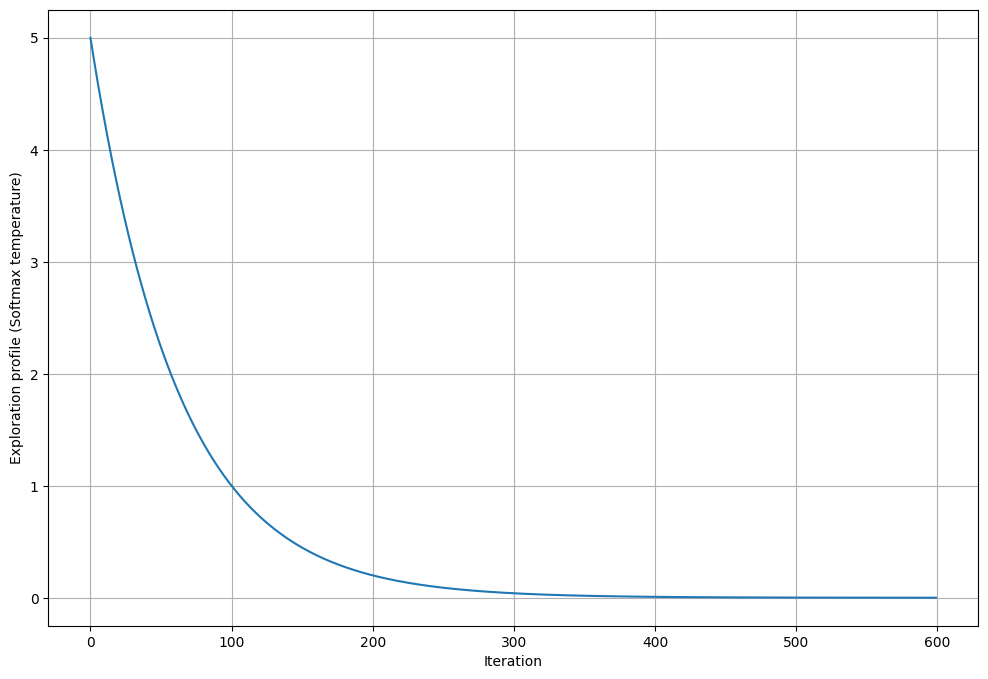

In [25]:
### Define exploration profile
initial_value = 5
#num_iterations = 800
#num_iterations = 10
num_iterations = 600 #600
exp_decay = np.exp(-np.log(initial_value) / num_iterations * 6) # We compute the exponential decay in such a way the shape of the exploration profile does not depend on the number of iterations
exploration_profile = [initial_value * (exp_decay ** i) for i in range(num_iterations)]
score_low_bound = -500#-2000 ###change add score low bound


### Plot exploration profile
plt.figure(figsize=(12,8))
plt.plot(exploration_profile)
plt.grid()
plt.xlabel('Iteration')
plt.ylabel('Exploration profile (Softmax temperature)')

In [26]:
### Create environment
env =  Custom_AcrobotEnv()
env.seed(0) # Set a random seed for the environment (reproducible results)
# Get the shapes of the state space (observation_space) and action space (action_space)
state_space_dim = env.observation_space.shape[0]
action_space_dim = env.action_space.n
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"STATE SPACE SIZE: {state_space_dim}")
print(f"ACTION SPACE SIZE: {action_space_dim}")

STATE SPACE SIZE: 6
ACTION SPACE SIZE: 3


/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [27]:
# Set random seeds
torch.manual_seed(0)
np.random.seed(0)

### PARAMETERS
gamma = 0.99   # gamma parameter for the long term reward
replay_memory_capacity = 10000   # Replay memory capacity
lr = 1e-3 # Optimizer learning rate
target_net_update_steps = 10   # Number of episodes to wait before updating the target network
batch_size = 256   # Number of samples to take from the replay memory for each update
bad_state_penalty = 0   # Penalty to the reward when we are in a bad state (in this case when the pole falls down)
min_samples_for_training = 1000   # Minimum samples in the replay memory to enable the training

In [28]:
### Initialize the replay memory
replay_mem = ReplayMemory(replay_memory_capacity)

### Initialize the policy network
policy_net = DQN(state_space_dim, action_space_dim).to(device)

### Initialize the target network with the same weights of the policy network
target_net = DQN(state_space_dim, action_space_dim).to(device)
target_net.load_state_dict(policy_net.state_dict()) # This will copy the weights of the policy network to the target network

### Initialize the optimizer
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr) # The optimizer will update ONLY the parameters of the policy network

### Initialize the loss function (Huber loss)
loss_fn = nn.SmoothL1Loss()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
def update_step(policy_net, target_net, replay_mem, gamma, optimizer, loss_fn, batch_size):

    # Sample the data from the replay memory
    batch = replay_mem.sample(batch_size)
    batch_size = len(batch)
    #print(type(batch)) #batch = np.array(batch)

    # Create tensors for each element of the batch
    states      = torch.tensor([s[0] for s in batch], dtype=torch.float32, device=device)
    actions     = torch.tensor([s[1] for s in batch], dtype=torch.int64, device=device)
    rewards     = torch.tensor([s[3] for s in batch], dtype=torch.float32, device=device)

    # Compute a mask of non-final states (all the elements where the next state is not None)
    non_final_next_states = torch.tensor([s[2] for s in batch if s[2] is not None], dtype=torch.float32, device=device) # the next state can be None if the game has ended
    non_final_mask = torch.tensor([s[2] is not None for s in batch], dtype=torch.bool)

    # Compute all the Q values (forward pass)
    policy_net.train()
    q_values = policy_net(states)
    # Select the proper Q value for the corresponding action taken Q(s_t, a)
    #state_action_values = q_values.gather(1, actions.unsqueeze(1).cuda())
    state_action_values = q_values.gather(1, actions.unsqueeze(1).to(device))
    #er0r
    # Compute the value function of the next states using the target network V(s_{t+1}) = max_a( Q_target(s_{t+1}, a)) )
    with torch.no_grad():
      target_net.eval()
      q_values_target = target_net(non_final_next_states)
    next_state_max_q_values = torch.zeros(batch_size, device=device)
    next_state_max_q_values[non_final_mask] = q_values_target.max(dim=1)[0].detach()

    # Compute the expected Q values
    expected_state_action_values = rewards + (next_state_max_q_values * gamma)
    expected_state_action_values = expected_state_action_values.unsqueeze(1)# Set the required tensor shape

    # Compute the Huber loss
    loss = loss_fn(state_action_values, expected_state_action_values)

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # Apply gradient clipping (clip all the gradients greater than 2 for training stability)
    nn.utils.clip_grad_norm_(policy_net.parameters(), 2)
    optimizer.step()



In [30]:
# Initialize the Gym environment
#env = gym.make('Acrobot-v1')
env =  Custom_AcrobotEnv()
env.seed(0) # Set a random seed for the environment (reproducible results)

# This is for creating the output video in Colab, not required outside Colab
#env = wrap_env(env, video_callable=lambda episode_id: episode_id % 100 == 0) # Save a video every 100 episodes

plotting_rewards=[]

save_observation = []
save_wanted_torque = [0]
save_actual_torque = [0]
save_sp_torque = [0]
save_ctrl_voltage = [0]


/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [ ]:
for episode_num, tau in enumerate(tqdm(exploration_profile)):

    #if episode_num == int(len(exploration_profile)/3):

    # Reset the environment and get the initial state
    state = env.reset()
    if episode_num == len(exploration_profile) - 1 :########
      save_observation.append(state)

    #state = state[0]###################################################################################################################################################
    # Reset the score. The final score will be the total amount of steps before the pole falls
    score = 0
    done = False
    # Go on until the pole falls off
    while not done:

      # Choose the action following the policy
      action, q_values = choose_action_softmax(policy_net, state, temperature=tau)

      # Apply the action and get the next state, the reward and a flag "done" that is True if the game is ended
      next_state, reward, done, info, wanted_torque , actual_torque = env.step(action)########
      if episode_num == len(exploration_profile) - 1 :########
        save_observation.append(next_state)
        save_wanted_torque.append(wanted_torque)
        save_actual_torque.append(actual_torque)
        save_sp_torque[-1] = env.MPC.y_spf
        save_sp_torque.append(env.MPC.y_spf)
        save_ctrl_voltage[-1] = env.MPC.plant.voltage_input
        save_ctrl_voltage.append(0)
    #end if

      # Update the final score (+1 for each step)
      score += reward

      if score<score_low_bound: ##### change  to stop high negative score
        done =True


      # Apply penalty for bad state

      if done: # if the pole has fallen down
          reward += bad_state_penalty
          next_state = None

      # Update the replay memory
      replay_mem.push(state, action, next_state, reward)

      # Update the network
      if len(replay_mem) > min_samples_for_training: # we enable the training only if we have enough samples in the replay memory, otherwise the training will use the same samples too often
          update_step(policy_net, target_net, replay_mem, gamma, optimizer, loss_fn, batch_size)

      # Visually render the environment (disable to speed up the training)
      #env.render()

      # Set the current state for the next iteration
      state = next_state

    # Update the target network every target_net_update_steps episodes
    if episode_num % target_net_update_steps == 0 : #score<score_low_bound:
        print('Updating target network...')
        target_net.load_state_dict(policy_net.state_dict()) # This will copy the weights of the policy network to the target network

    plotting_rewards.append(score)
    # Print the final score
    print(f"EPISODE: {episode_num + 1} - FINAL SCORE: {score}") # Print the final score

env.close()

  0%|          | 0/600 [00:00<?, ?it/s]

Updating target network...
EPISODE: 1 - FINAL SCORE: -501.0


/tmp/ipykernel_1777/177067022.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states      = torch.tensor([s[0] for s in batch], dtype=torch.float32, device=device)


EPISODE: 2 - FINAL SCORE: -501.0
EPISODE: 3 - FINAL SCORE: -501.0
EPISODE: 4 - FINAL SCORE: -501.0
EPISODE: 5 - FINAL SCORE: -501.0
EPISODE: 6 - FINAL SCORE: -501.0
EPISODE: 7 - FINAL SCORE: -501.0
EPISODE: 8 - FINAL SCORE: -501.0
EPISODE: 9 - FINAL SCORE: -501.0
EPISODE: 10 - FINAL SCORE: -501.0
Updating target network...
EPISODE: 11 - FINAL SCORE: -501.0
EPISODE: 12 - FINAL SCORE: -501.0
EPISODE: 13 - FINAL SCORE: -444.0
EPISODE: 14 - FINAL SCORE: -501.0
EPISODE: 15 - FINAL SCORE: -501.0
EPISODE: 16 - FINAL SCORE: -501.0
EPISODE: 17 - FINAL SCORE: -501.0
EPISODE: 18 - FINAL SCORE: -501.0
EPISODE: 19 - FINAL SCORE: -501.0
EPISODE: 20 - FINAL SCORE: -501.0
Updating target network...
EPISODE: 21 - FINAL SCORE: -501.0
EPISODE: 22 - FINAL SCORE: -501.0
EPISODE: 23 - FINAL SCORE: -501.0
EPISODE: 24 - FINAL SCORE: -501.0
EPISODE: 25 - FINAL SCORE: -501.0
EPISODE: 26 - FINAL SCORE: -501.0
EPISODE: 27 - FINAL SCORE: -501.0
EPISODE: 28 - FINAL SCORE: -501.0
EPISODE: 29 - FINAL SCORE: -501.0
EP

In [ ]:
plotting_rewards_test=[]
#env.seed(1) # Set a random seed for the environment (reproducible results)
total_episodes_test = 100
best_score = -501

In [ ]:
# Test
# Initialize the Gym environment

print('Test')
for num_episode in range(total_episodes_test):
    # Reset the environment and get the initial state
    state = env.reset()
    #state = state[0]##################################################################################################################################
    save_observation_temp = [state]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]

    # Reset the score. The final score will be the total amount of steps before the pole falls
    score = 0
    done = False
    # Go on until the pole falls off or the score reach 490
    while not done:
      # Choose the best action (temperature 0)
      action, q_values = choose_action_softmax(policy_net, state, temperature=0)
      # Apply the action and get the next state, the reward and a flag "done" that is True if the game is ended
      next_state, reward, done, info , wanted_torque, actual_torque = env.step(action)
      # Visually render the environment
      #env.render()
      # Update the final score (+1 for each step)
      score += reward
      # Set the current state for the next iteration
      state = next_state
      # Check if the episode ended (the pole fell down)
      if score<score_low_bound: ##### change  to stop high negative score
        done =True
      save_observation_temp.append(next_state)
      save_wanted_torque_temp.append(wanted_torque)
      save_actual_torque_temp.append(actual_torque)
      save_sp_torque_temp.append(env.MPC.y_spf)
      save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
      save_ctrl_voltage_temp.append(0.0)

    # get best score and update save data
    if best_score<score:
      save_observation = list(save_observation_temp)
      save_wanted_torque = list(save_wanted_torque_temp)
      save_actual_torque = list(save_actual_torque_temp)
      save_sp_torque = list(save_sp_torque_temp)
      #save_ctrl_voltage_temp.append(env.MPC.plant.voltage_input)
      save_ctrl_voltage = list(save_ctrl_voltage_temp)
      best_score = score


    # Print the final score
    plotting_rewards_test.append(score)
    print(f"EPISODE {num_episode} - FINAL SCORE: {score}")
env.close()

Test
EPISODE 0 - FINAL SCORE: -73.0
EPISODE 1 - FINAL SCORE: -99.0
EPISODE 2 - FINAL SCORE: -93.0
EPISODE 3 - FINAL SCORE: -93.0
EPISODE 4 - FINAL SCORE: -76.0
EPISODE 5 - FINAL SCORE: -66.0
EPISODE 6 - FINAL SCORE: -95.0
EPISODE 7 - FINAL SCORE: -105.0
EPISODE 8 - FINAL SCORE: -77.0
EPISODE 9 - FINAL SCORE: -92.0
EPISODE 10 - FINAL SCORE: -65.0
EPISODE 11 - FINAL SCORE: -104.0
EPISODE 12 - FINAL SCORE: -73.0
EPISODE 13 - FINAL SCORE: -103.0
EPISODE 14 - FINAL SCORE: -98.0
EPISODE 15 - FINAL SCORE: -77.0
EPISODE 16 - FINAL SCORE: -64.0
EPISODE 17 - FINAL SCORE: -309.0
EPISODE 18 - FINAL SCORE: -78.0
EPISODE 19 - FINAL SCORE: -90.0
EPISODE 20 - FINAL SCORE: -76.0
EPISODE 21 - FINAL SCORE: -74.0
EPISODE 22 - FINAL SCORE: -103.0
EPISODE 23 - FINAL SCORE: -92.0
EPISODE 24 - FINAL SCORE: -112.0
EPISODE 25 - FINAL SCORE: -78.0
EPISODE 26 - FINAL SCORE: -99.0
EPISODE 27 - FINAL SCORE: -92.0
EPISODE 28 - FINAL SCORE: -117.0
EPISODE 29 - FINAL SCORE: -96.0
EPISODE 30 - FINAL SCORE: -65.0
EPISOD

In [ ]:
save_observation_temp = None
save_observation_temp = None
save_wanted_torque_temp = None
save_actual_torque_temp = None
save_sp_torque_temp = None
save_ctrl_voltage_temp = None

In [ ]:
# Create a dictionary of variables you want to save
variables_to_save = {
    'plotting_rewards': plotting_rewards,
    'save_observation': save_observation,
    'save_wanted_torque': save_wanted_torque,
    'save_actual_torque': save_actual_torque,
    'save_sp_torque': save_sp_torque,
    'save_ctrl_voltage': save_ctrl_voltage,
    'plotting_rewards_test' :plotting_rewards_test
}

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Acrobot/'

In [ ]:
with open(path+'Acrobot.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Acrobot.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Acrobot/Acrobot.pkl


In [ ]:
torch.save(policy_net, path+"policy_net.pickle")

In [31]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Acrobot/'

In [32]:
# Open the file in read-binary mode and load the dictionary
with open(path+'Acrobot.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
plotting_rewards = loaded_variables['plotting_rewards']
save_observation = loaded_variables['save_observation']
save_wanted_torque = loaded_variables['save_wanted_torque']
save_actual_torque = loaded_variables['save_actual_torque']
save_sp_torque = loaded_variables['save_sp_torque']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
plotting_rewards_test = loaded_variables['plotting_rewards_test']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net_temp = torch.load(path+"policy_net.pickle",weights_only=False).to(device)

In [33]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [34]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [35]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [36]:
low_bound_reward_list = -500 # -0.1*(1**2 force mag)*(1000*episoded)s
up_bound_reward_list = 0
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
norm_reward_list = np.array(plotting_rewards)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -500
up_bound_reward_list= 0


/tmp/ipykernel_3454/252990024.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


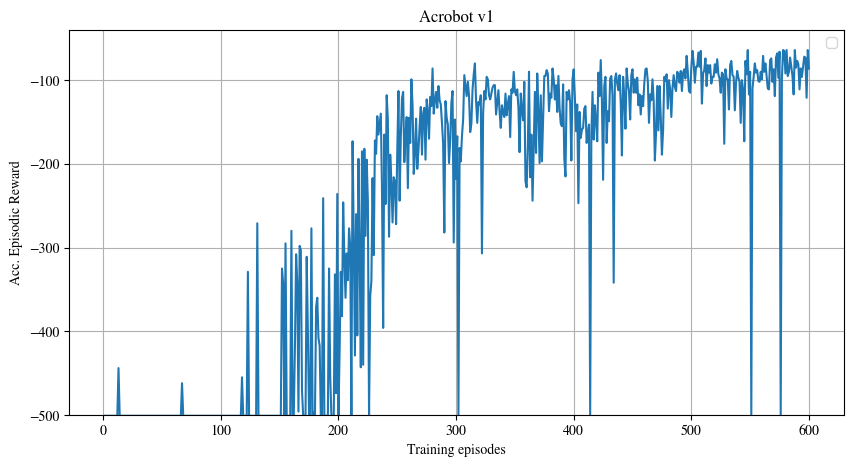

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1,num_iterations+1),plotting_rewards)
plt.xlabel('Training episodes')
plt.ylabel('Acc. Episodic Reward')
plt.ylim([-500,-40])
plt.legend()
plt.title('Acrobot v1')
plt.grid()
plt.show()

In [38]:
print(type(plotting_rewards))

<class 'list'>


In [39]:
N=50
# Compute the moving average of the last N numbers
moving_average = []
for i, n in enumerate(plotting_rewards):
    if i < 50:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(plotting_rewards[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(plotting_rewards[i-50:i+1]) / 50
    moving_average.append(avg)



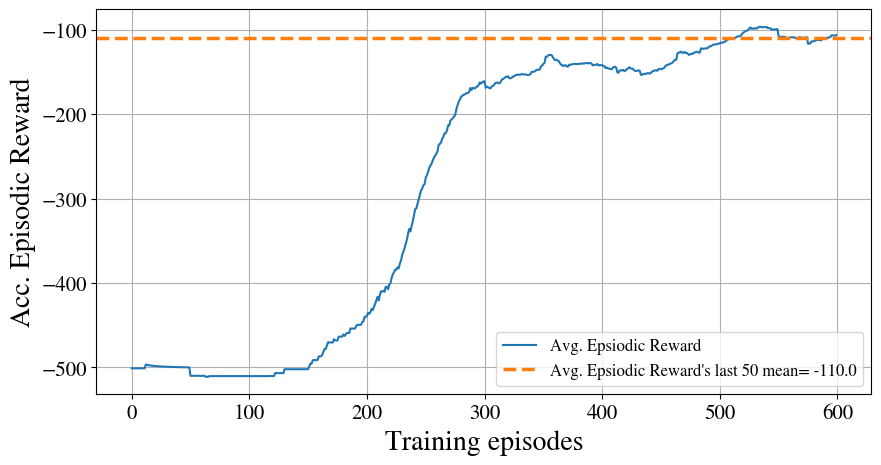

In [40]:
# Plot the moving average

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(moving_average, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(moving_average)[-N:-1].mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's last " +f"{N} "  "mean= "+f"{np.array(moving_average)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel('Training episodes',fontsize=20)
plt.ylabel('Acc. Episodic Reward',fontsize=20)

plt.grid()
plt.legend(fontsize=12)
plt.show()

In [41]:
print("Last avg of", N, "Episodes = ", f"{np.array(moving_average)[-20:-1].mean():.1f}")

Last avg of 50 Episodes =  -110.0


In [42]:
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(norm_reward_list):
    if i < 50:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(norm_reward_list[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(norm_reward_list[i-50:i+1]) / 50
    moving_average.append(avg)

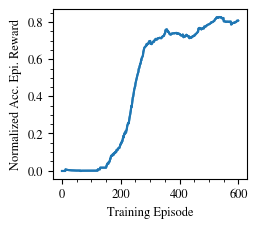

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
# Plot the moving average

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(moving_average)
plt.plot(moving_average, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=np.array(moving_average[-20:-1]).mean(), linestyle='--',
#            label = "Acc. Episodic Reward's last 20 mean= "+f"{np.array(moving_average[-20:-1]).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
plt.minorticks_on()
#plt.yticks(np.arange(0.0, 1.0, 0.1))
#plt.legend()
plt.savefig(path+"Acrobot_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [44]:
print("Normalized Acc. Episodic Reward's last 20 mean=")
print(np.array(moving_average[-20:-1]).mean())

Normalized Acc. Episodic Reward's last 20 mean=
0.8000505263157893


In [45]:
# Test Histogram
norm_ep_reward_list_test = np.array(plotting_rewards_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = np.floor(norm_ep_reward_list_test.min()*100)/100
print(min_bin)

0.872
-0.002
-0.01


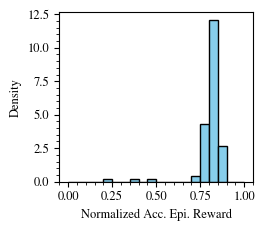

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [46]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
plt.hist(data_rewards, bins=np.arange(0,1.01,0.05), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. Epi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0.0,1.01,0.1))
#plt.xticks(np.arange(0,1.00001,0.05),minor=True)
plt.minorticks_on()
plt.savefig(path+"Acrobot_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [47]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=-64.000 ,mean=-104.950, std=71.210
Normalized:   max=8.720e-01 ,mean=7.901e-01, std=1.424e-01


In [48]:
dt=env.dt

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3454/3478285392.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_, save_sp_torque ,label = "$y^{\mathrm{sp}}=a^{RL}$ from RL alg. pre-filter",color="cyan",linestyle='-.',linewidth = 1.8)
/tmp/ipykernel_3454/3478285392.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_, save_wanted_torque ,label = "$y^{\mathrm{rm}}=a^{wanted}$ from AF-filter",color="blue",linewidth = 1.5)
/tmp/ipykernel_3454/3478285392.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$ from DC motor plant",color="red",linewidth = 4)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontcon

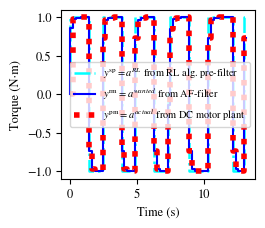

In [49]:
time_ = np.linspace(start = 0, stop = len(save_actual_torque)* dt,num=len(save_actual_torque) )

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
poly_fit = np.polynomial.polynomial.Polynomial.fit(x=time_[2:],y=e_ry[2:],deg=1,symbol='t')


plt.step(time_, save_sp_torque ,label = "$y^{\mathrm{sp}}=a^{RL}$ from RL alg. pre-filter",color="cyan",linestyle='-.',linewidth = 1.8)
plt.step(time_, save_wanted_torque ,label = "$y^{\mathrm{rm}}=a^{wanted}$ from AF-filter",color="blue",linewidth = 1.5)
plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$ from DC motor plant",color="red",linewidth = 4)
#plt.step(time_, e_ry,"--" ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$"+f": t≥"+str(2*dt)+"⇒"+"mean="+f'{e_ry[2:].mean():.4e}'+",\n std="+f'{e_ry[2:].std():.4e}'+", rms="+f'{np.sqrt((e_ry[2:]**2).mean()):.4e}'
#,color="black",linewidth = 2)
#plt.step(time_, e_ry ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 2)
#plt.axhline(y=e_ry.mean(), color="green",linewidth = 4, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')


plt.xlabel("Time (s)")
plt.ylabel(r"Torque (N⋅m)")
plt.legend(fontsize=7.5)#,bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.legend(fontsize=8.5)
plt.savefig(path+"Acrobot_Torque_vs_Time.pdf", format='pdf', bbox_inches='tight')
#plt.grid()
plt.show()

In [50]:
print("for t≥"+str(2*dt)+",n≥2:")
print('error≈',poly_fit)
print("mean=", f'{e_ry[2:].mean():.4e}')
print("std=", f'{e_ry[2:].std():.4e}')
print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.4,n≥2:
error≈ 3.59102081e-07 - (2.87651036e-07)·(-1.06349206 + 0.15632516t)
mean= 3.5910e-07
std= 2.0529e-06
rms= 2.0840e-06
mae= 2.0676e-06


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3454/3224808089.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
/tmp/ipykernel_3454/3224808089.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')


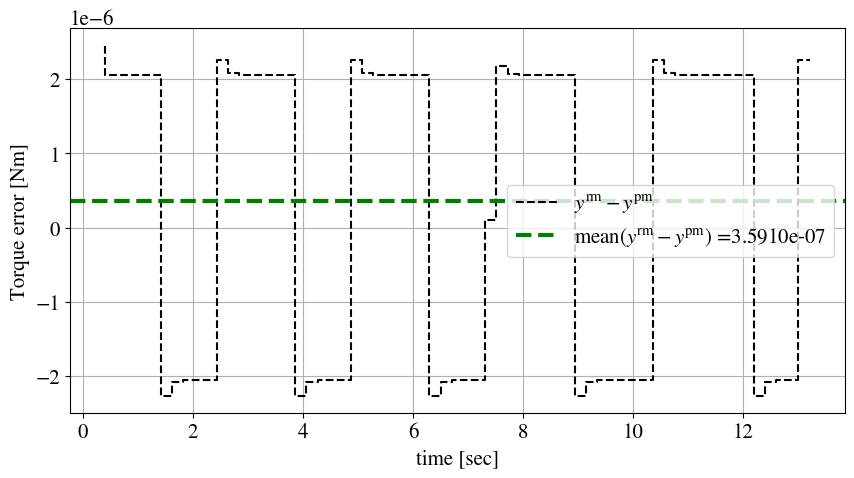

In [51]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)


plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')

plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=15)
#plt.legend(fontsize=10,bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()
plt.show()

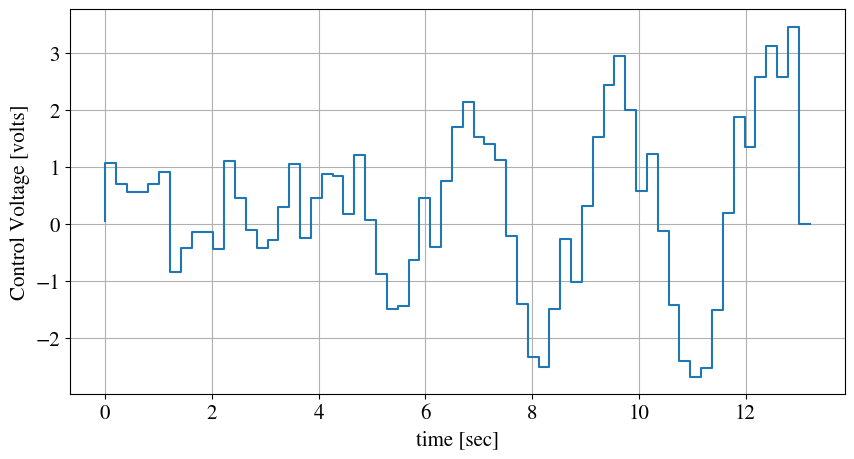

In [52]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

#time_u = np.linspace(start = 0, stop = len(save_ctrl_voltage)* dt,num=len(save_ctrl_voltage) )

plt.step(time_, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
plt.grid()
plt.show()

In [53]:
import math

cos_theta_1 = []
sin_theta_1 = []
cos_theta_2 = []
sin_theta_2 = []
ang_vel_theta_1 = []
ang_vel_theta_2 = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      cos_theta_1.append(value)
    if index == 1:
      sin_theta_1.append(value)
    if index == 2:
      cos_theta_2.append(value)
    if index == 3:
      sin_theta_2.append(value)
    if index == 4:
      ang_vel_theta_1.append(value)
    if index == 5:
      ang_vel_theta_2.append(value)

In [54]:
cos_theta_1 = np.array(cos_theta_1)
cos_theta_2 = np.array(cos_theta_2)
sin_theta_1 = np.array(sin_theta_1)
sin_theta_2 = np.array(sin_theta_2)
ang_vel_theta_1 = np.array(ang_vel_theta_1)
ang_vel_theta_2 = np.array(ang_vel_theta_2)

In [55]:
print(len(cos_theta_1))

66


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


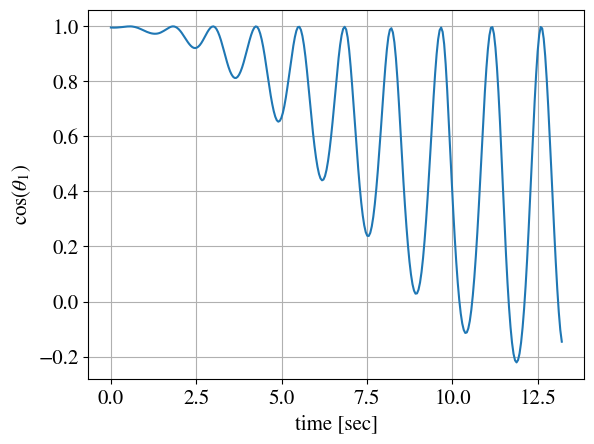

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [56]:
from scipy.interpolate import make_interp_spline, BSpline

time_cos_theta_1 = np.linspace(start = 0, stop = len(cos_theta_1)* dt,num=len(cos_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_cos_theta_1[-1] , 300)

spl = make_interp_spline(time_cos_theta_1, cos_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\cos({\theta_1})$')
plt.show()

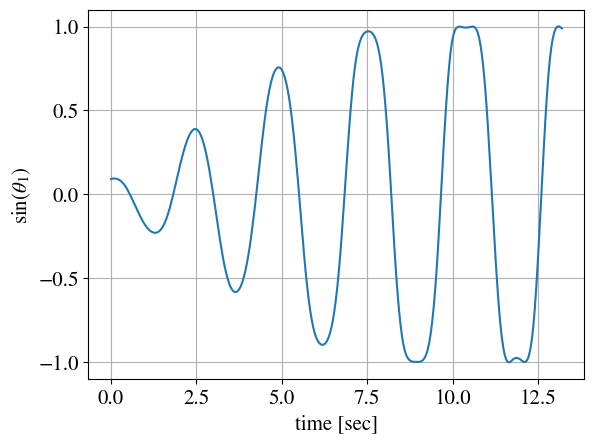

In [57]:
from scipy.interpolate import make_interp_spline, BSpline

time_sin_theta_1 = np.linspace(start = 0, stop = len(sin_theta_1)* dt,num=len(sin_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_sin_theta_1[-1] , 300)

spl = make_interp_spline(time_sin_theta_1, sin_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\sin({\theta_1})$')
plt.show()

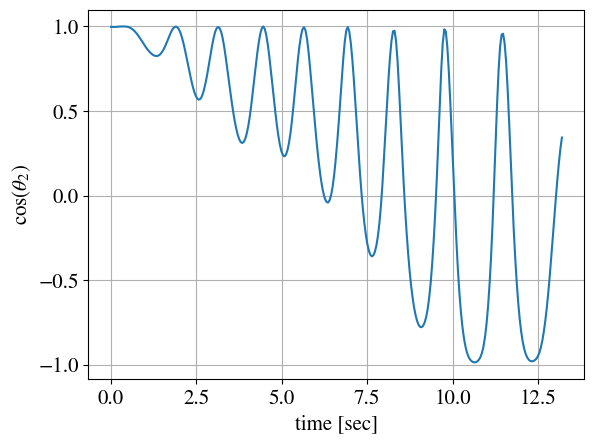

In [58]:
from scipy.interpolate import make_interp_spline, BSpline

time_cos_theta_2 = np.linspace(start = 0, stop = len(cos_theta_2)* dt,num=len(cos_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_cos_theta_2[-1] , 300)

spl = make_interp_spline(time_cos_theta_2, cos_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\cos({\theta_2})$')
plt.show()

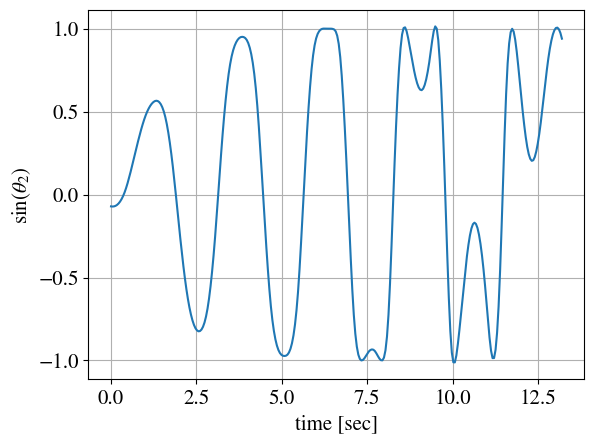

In [59]:
from scipy.interpolate import make_interp_spline, BSpline

time_sin_theta_2 = np.linspace(start = 0, stop = len(sin_theta_2)* dt,num=len(sin_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_sin_theta_2[-1] , 300)

spl = make_interp_spline(time_sin_theta_2, sin_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\sin({\theta_2})$')
plt.show()

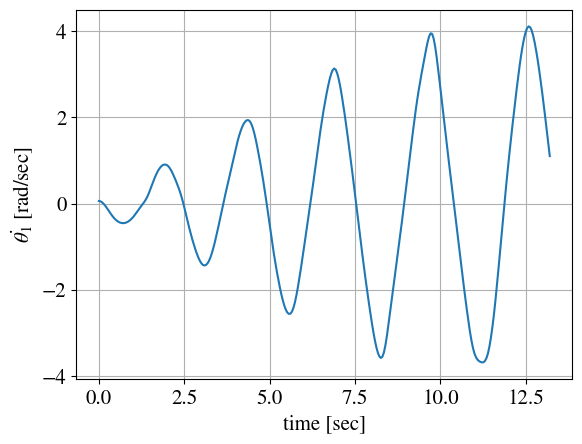

In [60]:
from scipy.interpolate import make_interp_spline, BSpline

time_ang_vel_theta_1 = np.linspace(start = 0, stop = len(ang_vel_theta_1)* dt,num=len(ang_vel_theta_1))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_ang_vel_theta_1[-1] , 300)

spl = make_interp_spline(time_ang_vel_theta_1, ang_vel_theta_1, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta_1}$ [rad/sec]')
plt.show()

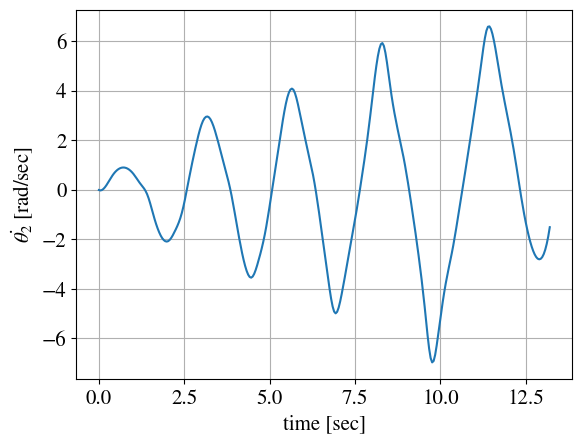

In [61]:
from scipy.interpolate import make_interp_spline, BSpline

time_ang_vel_theta_2 = np.linspace(start = 0, stop = len(ang_vel_theta_2)* dt,num=len(ang_vel_theta_2))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_ang_vel_theta_2[-1] , 300)

spl = make_interp_spline(time_ang_vel_theta_2, ang_vel_theta_2, k=3)  # type: BSpline
power_smooth = spl(xnew)

plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta_2}$ [rad/sec]')
plt.show()

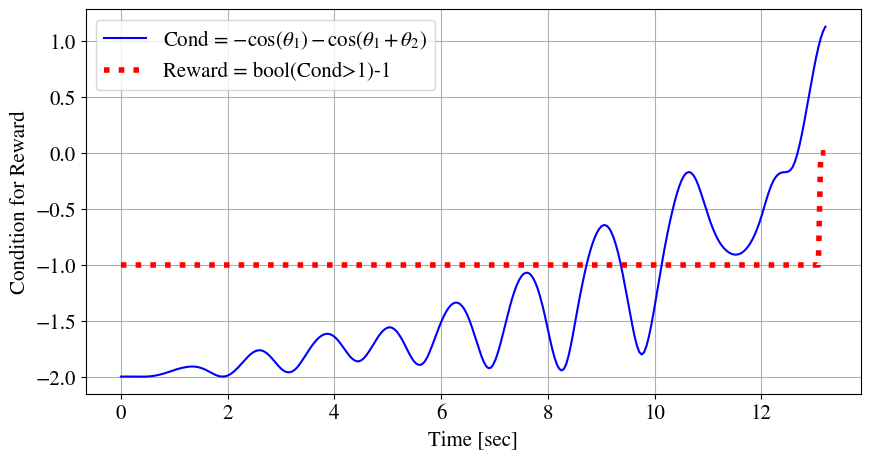

In [62]:
Condition = -cos_theta_1 -cos_theta_1*cos_theta_2 + sin_theta_1*sin_theta_2
spl = make_interp_spline(time_sin_theta_2, Condition, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth, label = r'Cond = $-\cos(\theta_1)-\cos({\theta_1+\theta_2})$',color="blue")
plt.plot(xnew, (power_smooth>1)-1,':', label = r'Reward = bool(Cond>1)-1',color="red", linewidth = 4)

plt.grid()
#plt.legend()
plt.xlabel("Time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel('Condition for Reward')
plt.legend()
plt.show()

In [63]:
print("Goal obtained after", f"{xnew[-1]:.1f}","sec")

Goal obtained after 13.2 sec


In [64]:
# Initialize the Gym environment
env =  Custom_AcrobotEnv()
env.seed(1) # Set a random seed for the environment (reproducible results)

# This is for creating the output video in Colab, not required outside Colab
#env = wrap_env(env, video_callable=lambda episode_id: True) # Save a video every episode

plotting_rewards2=[]
# Let's try for a total of 10 episodes
for num_episode in range(10):
    # Reset the environment and get the initial state
    state = env.reset()
    #state = state[0]##################################################################################################################################
    # Reset the score. The final score will be the total amount of steps before the pole falls
    score = 0
    done = False
    # Go on until the pole falls off or the score reach 490
    while not done:
      # Choose the best action (temperature 0)
      action, q_values = choose_action_softmax(policy_net, state, temperature=0)
      #action, q_values = choose_action_softmax(target_net, state, temperature=0)

      # Apply the action and get the next state, the reward and a flag "done" that is True if the game is ended
      next_state, reward, done, info , wanted_torque, actual_torque = env.step(action)
      # Visually render the environment
      #env.render()
      # Update the final score (+1 for each step)
      score += reward
      # Set the current state for the next iteration
      state = next_state
      # Check if the episode ended (the pole fell down)
      if score<=-500:#score_low_bound: ##### change  to stop high negative score
        done =True
    # Print the final score
    plotting_rewards2.append(score)
    print(f"EPISODE {num_episode + 1} - FINAL SCORE: {score}")
env.close()

/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


EPISODE 1 - FINAL SCORE: -500.0
EPISODE 2 - FINAL SCORE: -500.0
EPISODE 3 - FINAL SCORE: -500.0
EPISODE 4 - FINAL SCORE: -500.0
EPISODE 5 - FINAL SCORE: -500.0
EPISODE 6 - FINAL SCORE: -500.0
EPISODE 7 - FINAL SCORE: -500.0
EPISODE 8 - FINAL SCORE: -500.0
EPISODE 9 - FINAL SCORE: -500.0
EPISODE 10 - FINAL SCORE: -500.0


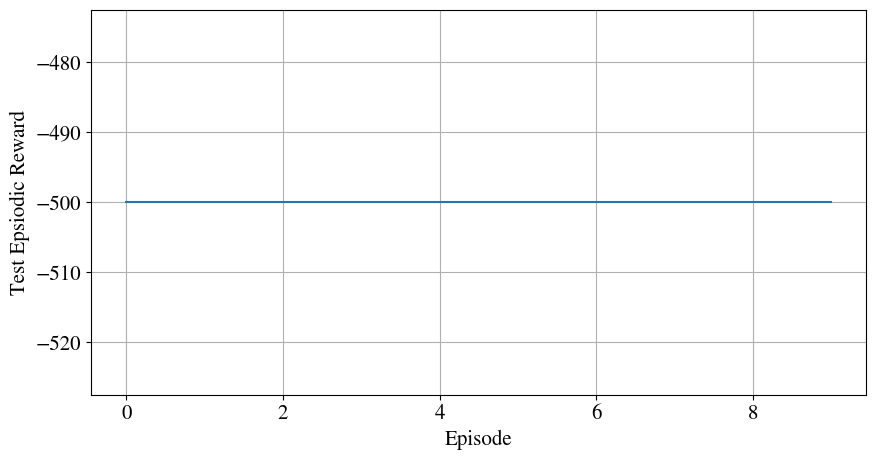

In [65]:

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(plotting_rewards2)
plt.xlabel("Episode")
plt.ylabel("Test Epsiodic Reward")
plt.grid()
plt.show()